# 台风风场纵向剖面（EW / SN）

- 数据：`Supplementary/results_sections_all/section_{EW|SN}_{case}_{lead}_2025-09-23_22.nc`
- 只考虑 ERA5 驱动的三组地表条件（绝对场）：`era5_no_lcz_no_srtm`、`era5_no_lcz`、`era5`
- 填色：风速 $\sqrt{ua^2+va^2}$（colormap: `coolwarm`）
- 输出：`Supplementary/publish/wind_cross_section_20250923_22_{24h|48h}.tif`

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ----------------------------------------------------------------------------
# Settings
# ----------------------------------------------------------------------------
VALID_TAG = "2025-09-23_22"  # file tag in results_sections_all
VALID_TAG_OUT = "20250923_22"  # output tag (no separators)
LEADS = ["24h", "48h"]
SECTIONS = ["EW", "SN"]

# ERA5-driven surface-condition cases (absolute fields)
CASE_ORDER = [
    "era5_no_lcz_no_srtm",  # Low terrain / Low LCZ
    "era5_no_lcz",  # High terrain / Low LCZ
    "era5",  # High terrain / High LCZ
]

CASE_META: dict[str, dict[str, str]] = {
    "era5_no_lcz_no_srtm": {"label": "Low terrain\nLow LCZ"},
    "era5_no_lcz": {"label": "High terrain\nLow LCZ"},
    "era5": {"label": "High terrain\nHigh LCZ"},
}

# ----------------------------------------------------------------------------
# Paths (robust to CWD)
# NOTE: VS Code notebooks sometimes run with CWD = workspace root.
#       The fallback below makes paths work whether CWD is Supplementary/ or its parent.
# ----------------------------------------------------------------------------
FIG_DIR = Path("Supplementary") if Path("Supplementary").is_dir() else Path(".")
ROOT_DIR = FIG_DIR.resolve().parent

RESULTS_DIR = FIG_DIR / "results_sections_all"
PUBLISH_DIR = FIG_DIR / "publish"
PUBLISH_DIR.mkdir(parents=True, exist_ok=True)

print("[Paths]")
print("  NOTEBOOK =", FIG_DIR.resolve().as_posix())
print("  RESULTS  =", RESULTS_DIR.resolve().as_posix())
print("  PUBLISH  =", PUBLISH_DIR.resolve().as_posix())

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Missing results directory: {RESULTS_DIR.resolve().as_posix()}")

# ----------------------------------------------------------------------------
# Plot style
# ----------------------------------------------------------------------------
_avail_fonts = {f.name for f in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in _avail_fonts else "DejaVu Sans"
mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.sans-serif": [FONT_FAMILY],
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)
print("[Font] Using:", FONT_FAMILY)

# ----------------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------------


def save_tiff(fig: "plt.Figure", out_path: Path, dpi: int = 600) -> None:
    """Save a TIFF; tries LZW compression if supported."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    common = dict(dpi=dpi, format="tiff", bbox_inches="tight")
    try:
        fig.savefig(out_path, pil_kwargs={"compression": "tiff_lzw"}, **common)
    except TypeError:
        fig.savefig(out_path, **common)


def section_path(section: str, case_key: str, lead: str) -> Path:
    section = section.upper()
    return RESULTS_DIR / f"section_{section}_{case_key}_{lead}_{VALID_TAG}.nc"


def _horiz_dim(section: str) -> str:
    section = section.upper()
    if section == "EW":
        return "west_east"
    if section == "SN":
        return "south_north"
    raise ValueError(f"Unknown section: {section}")


def _x_var(section: str) -> str:
    section = section.upper()
    return "lon" if section == "EW" else "lat"


def _as_1d_along(da: xr.DataArray, dim: str) -> np.ndarray:
    """Reduce an array to 1D along `dim` by selecting index 0 on other dims."""
    if dim not in da.dims:
        raise ValueError(f"Expected dim '{dim}' in {da.name or 'array'} dims={da.dims}")
    sel = {d: 0 for d in da.dims if d != dim}
    out = da.isel(sel) if sel else da
    out = out.transpose(dim)
    arr = np.asarray(out.values).squeeze()
    if arr.ndim != 1:
        raise ValueError(f"Expected 1D along '{dim}', got shape={arr.shape} dims={out.dims}")
    return arr.astype(float)


def _as_2d_bottom_top_horiz(da: xr.DataArray, *, horiz_dim: str) -> np.ndarray:
    lev_dim = "bottom_top"
    if lev_dim in da.dims and horiz_dim in da.dims:
        out = da.transpose(lev_dim, horiz_dim)
        return np.asarray(out.values, dtype=float)
    if lev_dim in da.dims and da.ndim == 1:
        # broadcast later to match horizontal length
        return np.asarray(da.transpose(lev_dim).values, dtype=float)[:, None]
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")


def extract_panel_arrays(ds: xr.Dataset, section: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x2d, z2d, wspd2d) arrays for plotting."""
    section = section.upper()
    horiz_dim = _horiz_dim(section)
    xname = _x_var(section)

    # x coordinate (1D)
    x1d = _as_1d_along(ds[xname], horiz_dim)

    # wind components + height (2D: bottom_top × horiz)
    ua = _as_2d_bottom_top_horiz(ds["ua"], horiz_dim=horiz_dim)
    va = _as_2d_bottom_top_horiz(ds["va"], horiz_dim=horiz_dim)
    z = _as_2d_bottom_top_horiz(ds["height"], horiz_dim=horiz_dim)

    wspd = np.hypot(ua, va)

    # broadcast x to 2D
    if x1d.size != wspd.shape[1]:
        raise ValueError(f"x length {x1d.size} != horizontal size {wspd.shape[1]} for section={section}")
    x2d = np.broadcast_to(x1d[None, :], wspd.shape)
    return x2d, z, wspd


def compute_vmax_for_lead(lead: str, percentile: float = 99.0) -> float:
    """Shared vmax across all panels for a given lead."""
    values: list[np.ndarray] = []
    for section in SECTIONS:
        for case_key in CASE_ORDER:
            path = section_path(section, case_key, lead)
            with xr.open_dataset(path) as ds:
                _, _, wspd = extract_panel_arrays(ds, section)
            values.append(wspd.ravel())

    allv = np.concatenate(values)
    allv = allv[np.isfinite(allv)]
    if allv.size == 0:
        raise ValueError(f"No finite wind-speed values for lead={lead}")

    vmax = float(np.nanpercentile(allv, percentile))
    if vmax <= 0:
        vmax = float(np.nanmax(allv))
    return vmax


def plot_cross_sections(lead: str, *, percentile: float = 99.0, vmax: float | None = None) -> tuple[plt.Figure, float]:
    """Plot one figure for a lead (24h/48h). Returns (fig, vmax)."""
    if vmax is None:
        vmax = compute_vmax_for_lead(lead, percentile=percentile)

    # Use contourf (less pixelated than pcolormesh for coarse sections)
    levels = np.linspace(0.0, vmax, 21)
    fig, axes = plt.subplots(
        nrows=len(CASE_ORDER),
        ncols=len(SECTIONS),
        figsize=(12, 10),
        sharey=True,
        constrained_layout=True,
    )

    last_mappable = None
    for i, case_key in enumerate(CASE_ORDER):
        for j, section in enumerate(SECTIONS):
            ax = axes[i, j]
            path = section_path(section, case_key, lead)
            with xr.open_dataset(path) as ds:
                x2d, z2d, wspd = extract_panel_arrays(ds, section)

            last_mappable = ax.contourf(
                x2d,
                z2d,
                wspd,
                levels=levels,
                cmap="coolwarm",
                extend="max",
            )

            # SN: show ticks like 22.2, 22.3, ... (one decimal)
            if section == "SN":
                ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.1))
                ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f"))

            if i == 0:
                ax.set_title(section)

            if i == len(CASE_ORDER) - 1:
                ax.set_xlabel("Longitude (°E)" if section == "EW" else "Latitude (°N)")

            if j == 0:
                ax.set_ylabel("Height (m)")
                ax.text(
                    0.02,
                    0.95,
                    CASE_META[case_key]["label"],
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                )

    if last_mappable is None:
        raise RuntimeError("Plotting failed: no mappable created")

    cbar = fig.colorbar(last_mappable, ax=axes, shrink=0.9, pad=0.02)
    vmax_round = int(np.ceil(vmax / 10.0) * 10)
    ticks = np.arange(0, vmax_round + 1, 10, dtype=int)
    if ticks.size > 0:
        cbar.set_ticks(ticks)
    cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    cbar.set_label("Wind speed (m s$^{-1}$)")

    fig.suptitle(f"Vertical cross-sections of wind speed ({lead})", y=1.02)
    return fig, vmax


def out_path_for_lead(lead: str) -> Path:
    return PUBLISH_DIR / f"wind_cross_section_{VALID_TAG_OUT}_{lead}.tif"

[Paths]
  NOTEBOOK = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary
  RESULTS  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary/results_sections_all
  PUBLISH  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary/publish
[Font] Using: Arial


[Saved] E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Supplementary\publish\wind_cross_section_20250923_22_24h.tif (vmax=69.45)


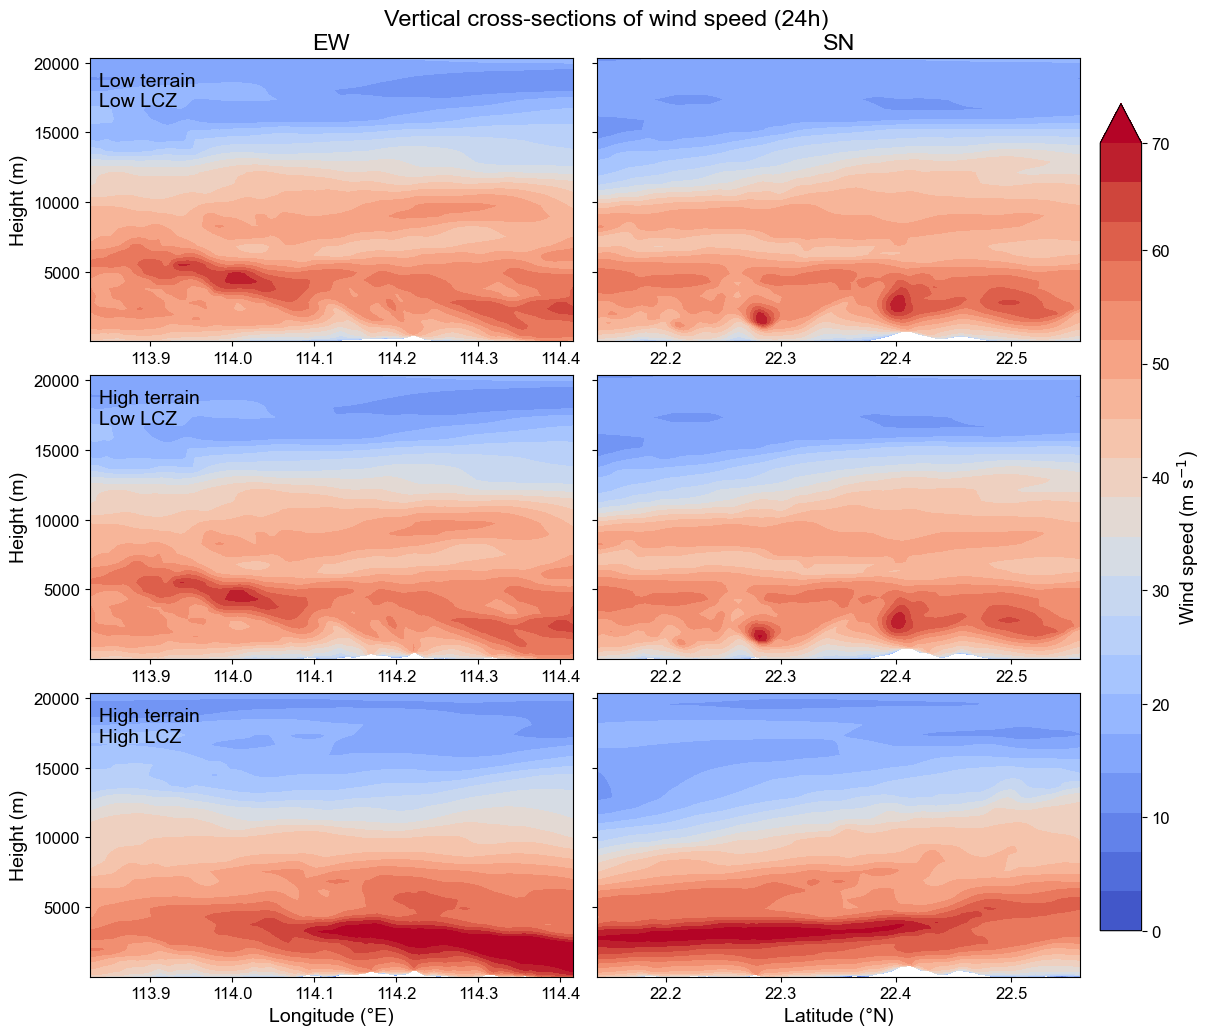

In [2]:
# --- Make & save 24h figure ---
lead = "24h"
fig, vmax = plot_cross_sections(lead, percentile=99.0)
out_path = out_path_for_lead(lead)
save_tiff(fig, out_path, dpi=600)
print(f"[Saved] {out_path.resolve()} (vmax={vmax:.2f})")
plt.show()
plt.close(fig)

[Saved] E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Supplementary\publish\wind_cross_section_20250923_22_48h.tif (vmax=68.57)


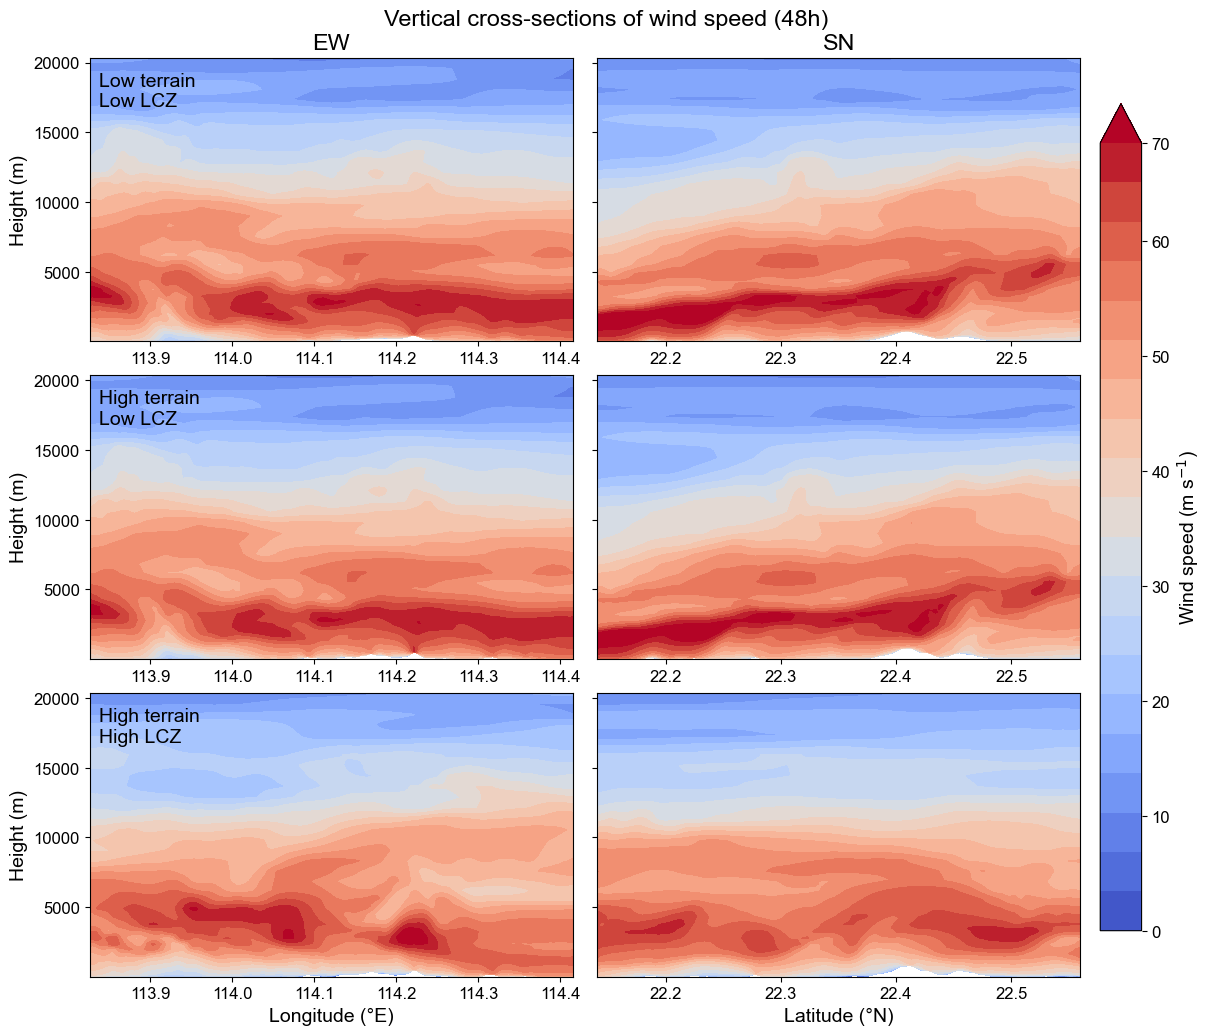

In [3]:
# --- Make & save 48h figure ---
lead = "48h"
fig, vmax = plot_cross_sections(lead, percentile=99.0)
out_path = out_path_for_lead(lead)
save_tiff(fig, out_path, dpi=600)
print(f"[Saved] {out_path.resolve()} (vmax={vmax:.2f})")
plt.show()
plt.close(fig)